In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno




In [16]:


df_train = pd.read_csv("train.csv")
df_test  = pd.read_csv("test.csv")

print(df_train.shape)   
df_train.head()



(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
nulos = df_train.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0])

Cabin       687
Age         177
Embarked      2
dtype: int64


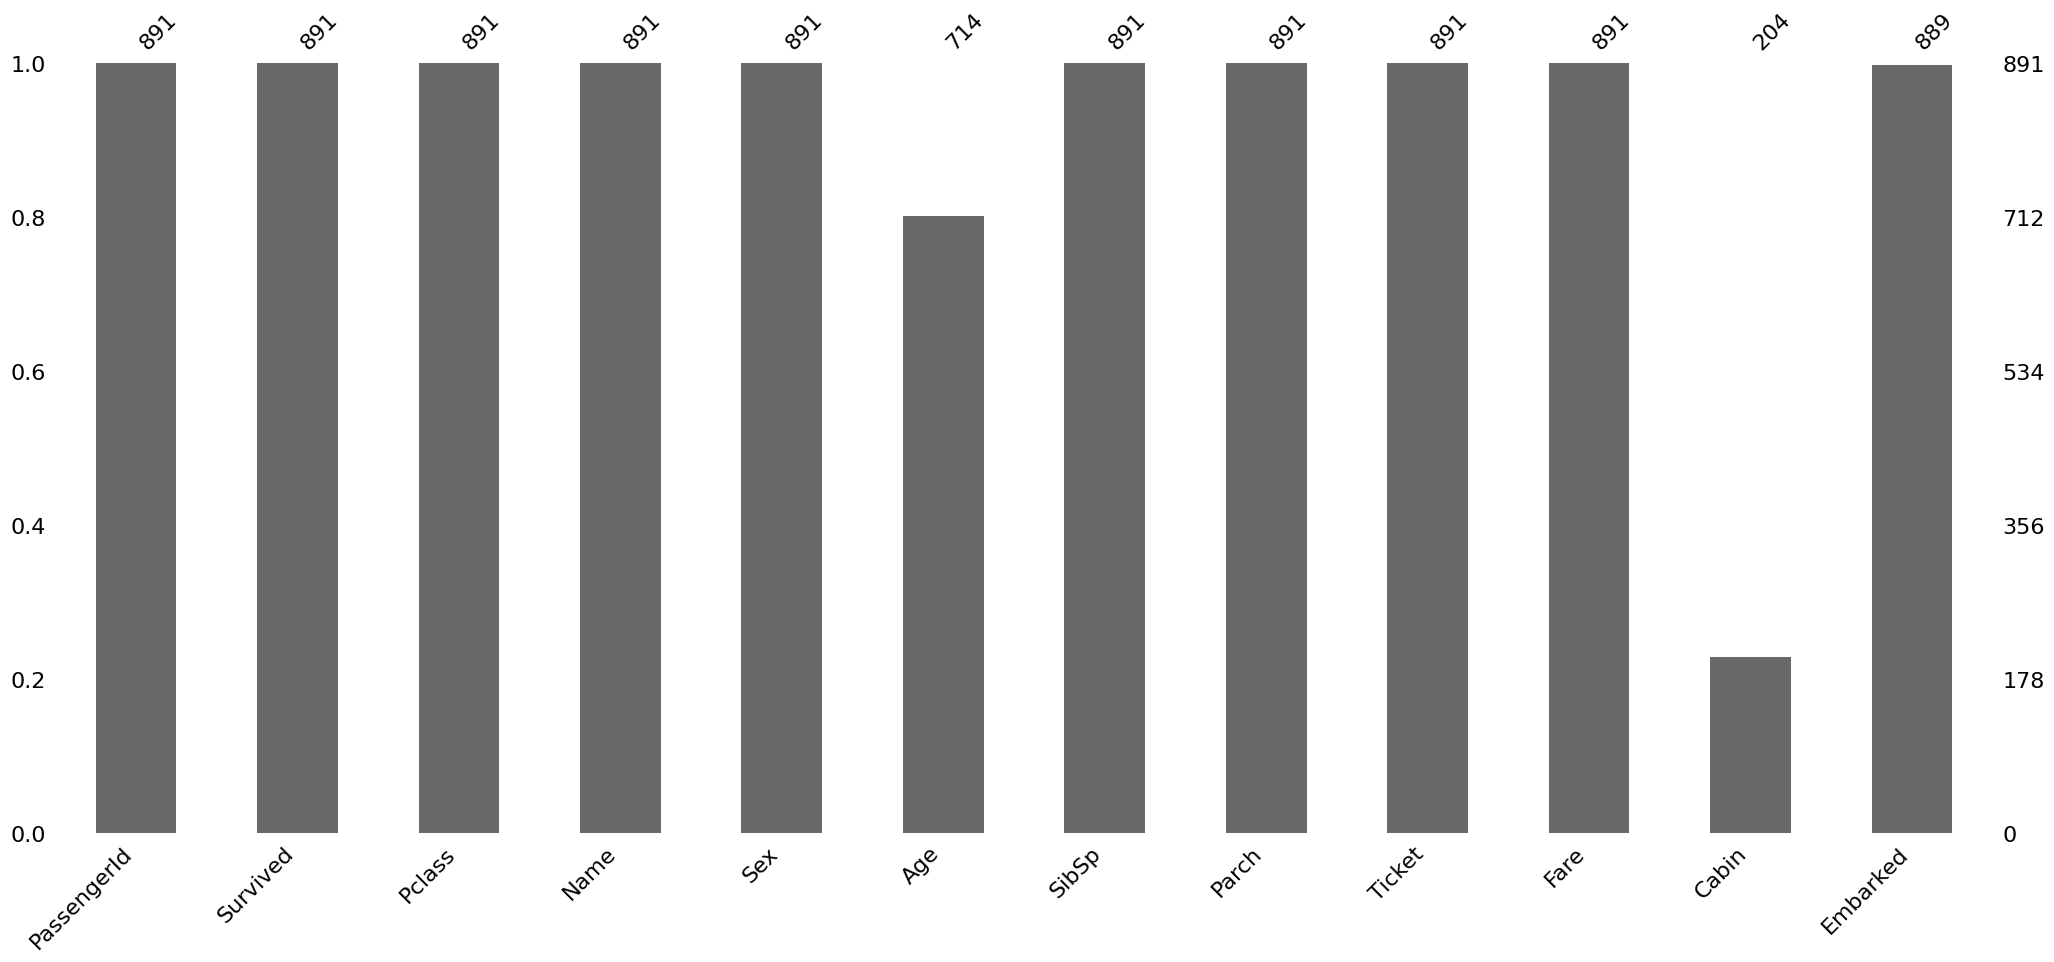

In [18]:
msno.bar(df_train)
plt.show()

In [19]:

df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())


df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])


if "Cabin" in df_train.columns:
    df_train.drop(columns=["Cabin"], inplace=True)


print(df_train.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_14684\214238061.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(["Não sobreviveu", "Sobreviveu"])


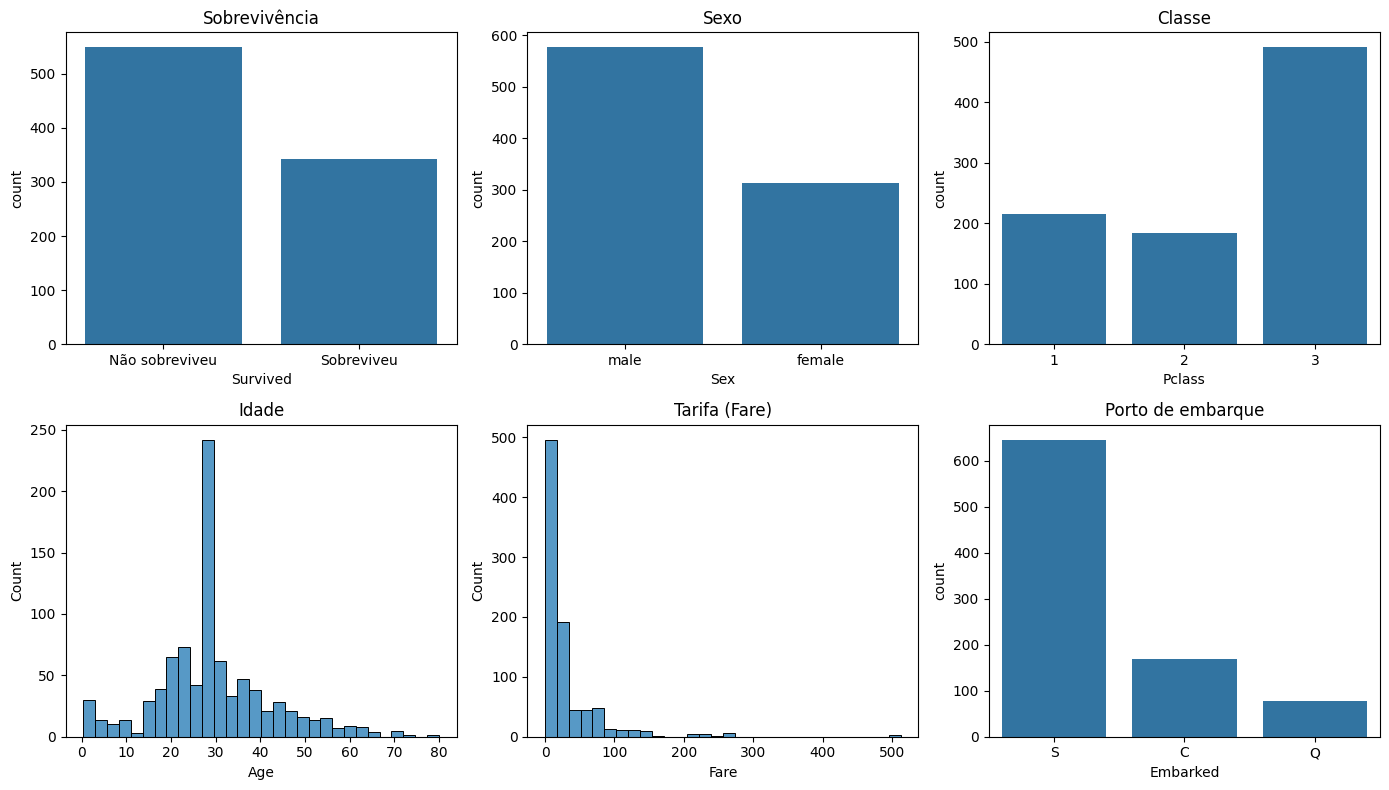

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))


sns.countplot(x="Survived", data=df_train, ax=axes[0,0])
axes[0,0].set_title("Sobrevivência")
axes[0,0].set_xticklabels(["Não sobreviveu", "Sobreviveu"])


sns.countplot(x="Sex", data=df_train, ax=axes[0,1])
axes[0,1].set_title("Sexo")


sns.countplot(x="Pclass", data=df_train, ax=axes[0,2])
axes[0,2].set_title("Classe")


sns.histplot(df_train["Age"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Idade")


sns.histplot(df_train["Fare"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Tarifa (Fare)")


sns.countplot(x="Embarked", data=df_train, ax=axes[1,2])
axes[1,2].set_title("Porto de embarque")

plt.tight_layout()
plt.show()

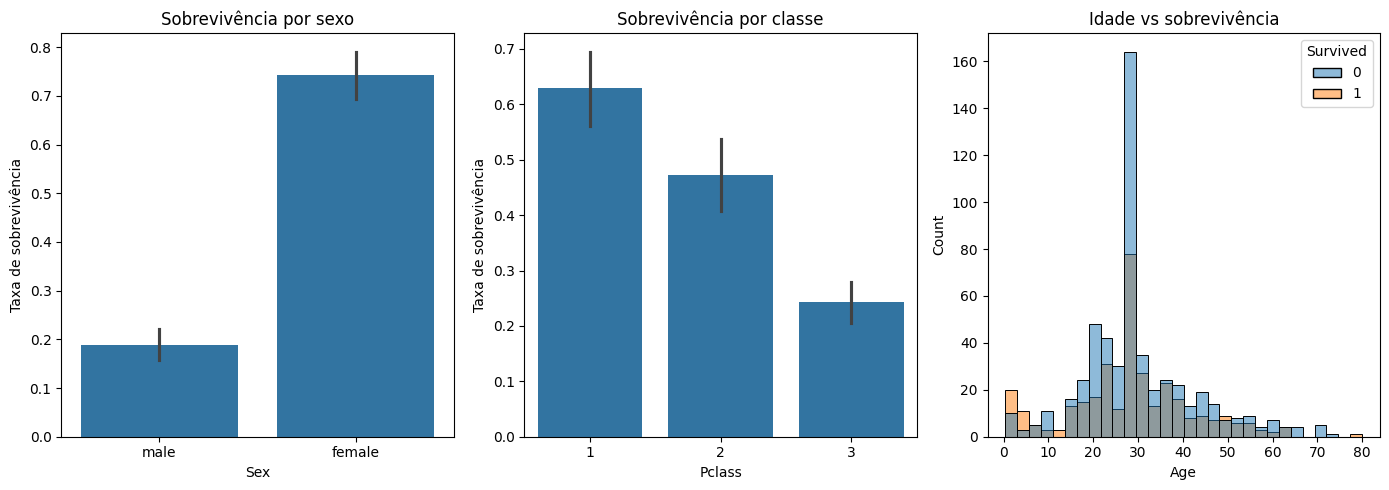

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))


sns.barplot(x="Sex", y="Survived", data=df_train, ax=axes[0])
axes[0].set_title("Sobrevivência por sexo")
axes[0].set_ylabel("Taxa de sobrevivência")


sns.barplot(x="Pclass", y="Survived", data=df_train, ax=axes[1])
axes[1].set_title("Sobrevivência por classe")
axes[1].set_ylabel("Taxa de sobrevivência")


sns.histplot(data=df_train, x="Age", hue="Survived", bins=30, ax=axes[2])
axes[2].set_title("Idade vs sobrevivência")

plt.tight_layout()
plt.show()


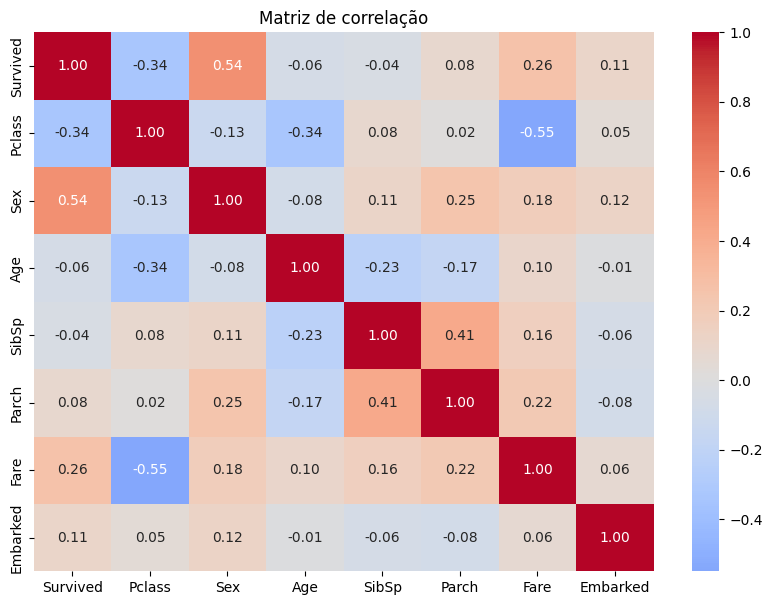

In [22]:

df_corr = df_train.copy()
df_corr["Sex"] = df_corr["Sex"].map({"male": 0, "female": 1})
df_corr["Embarked"] = df_corr["Embarked"].map({"S": 0, "C": 1, "Q": 2})


df_corr.drop(columns=["Name", "Ticket", "PassengerId"], inplace=True)

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação")
plt.show()

In [23]:

df_train["FamilySize"] = df_train["SibSp"] + df_train["Parch"] + 1


df_train["IsAlone"] = (df_train["FamilySize"] == 1).astype(int)


df_train["Title"] = df_train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df_train["Title"] = df_train["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare"
)
df_train["Title"] = df_train["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})


print(df_train["Title"].value_counts())
print("\nSobrevivência por tamanho de família:")
print(df_train.groupby("FamilySize")["Survived"].mean().round(2))

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Sobrevivência por tamanho de família:
FamilySize
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64


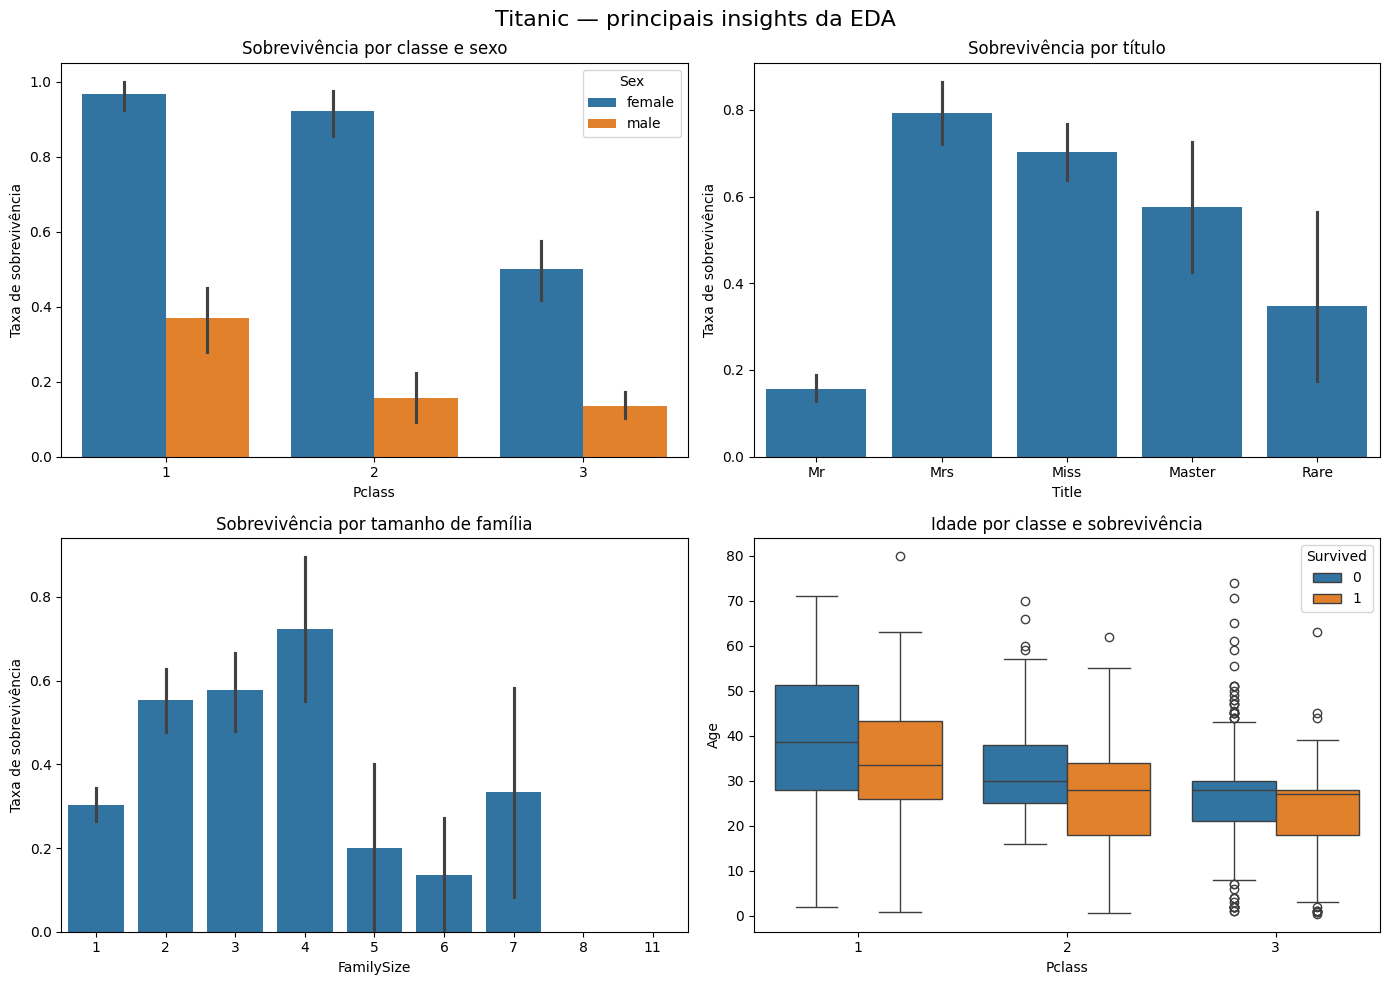

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic — principais insights da EDA", fontsize=16)


sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df_train, ax=axes[0,0])
axes[0,0].set_title("Sobrevivência por classe e sexo")
axes[0,0].set_ylabel("Taxa de sobrevivência")


sns.barplot(x="Title", y="Survived", data=df_train, ax=axes[0,1])
axes[0,1].set_title("Sobrevivência por título")
axes[0,1].set_ylabel("Taxa de sobrevivência")


sns.barplot(x="FamilySize", y="Survived", data=df_train, ax=axes[1,0])
axes[1,0].set_title("Sobrevivência por tamanho de família")
axes[1,0].set_ylabel("Taxa de sobrevivência")


sns.boxplot(x="Pclass", y="Age", hue="Survived", data=df_train, ax=axes[1,1])
axes[1,1].set_title("Idade por classe e sobrevivência")

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# EDA — Dataset Titanic (Kaggle)
# =============================================================

# Introdução:
# O Titanic foi um navio que naufragou em abril de 1912 após colidir com um iceberg,
# resultando na morte de mais de 1.500 pessoas. Este trabalho realiza uma Análise
# Exploratória de Dados (EDA) sobre o dataset disponível no Kaggle, com o objetivo
# de identificar os principais fatores que influenciaram a sobrevivência dos passageiros.

# =============================================================
# Perguntas norteadoras
# =============================================================

# 1. Qual foi a taxa geral de sobrevivência dos passageiros?
# 2. O sexo do passageiro influenciou a chance de sobrevivência?
# 3. A classe socioeconômica (Pclass) impactou a sobrevivência?
# 4. Crianças tiveram maior taxa de sobrevivência do que adultos?
# 5. Quais colunas tinham valores ausentes e como foram tratadas?
# 6. Viajar sozinho ou acompanhado de família afetou a sobrevivência?
# 7. O porto de embarque teve alguma relação com a sobrevivência?
# 8. Qual variável teve maior correlação com a sobrevivência?
# 9. O título social extraído do nome revelou padrões de sobrevivência?
# 10. A tarifa paga pelo bilhete estava relacionada à sobrevivência?